In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [22]:
# system parameters
m = 1.0
c = 0.5
k = 4.0

a1 = -k/m
a2 = -c/m
b1 = 1/m

print(f"a1 = {a1}, a2 ={a2}, b1 = {b1}")

a1 = -4.0, a2 =-0.5, b1 = 1.0


In [3]:
def F(t):
    u = 0.25 * np.random.randn()
    return u

In [4]:
def mass_spring_damp(t, state):
    # x(state) = x1, x1_dot
    x, x_dot, _ = state
    # m*x_ddot + c*x_dot + k*x = F (x = mass displacement)
    u = F(t)
    x_ddot = 1/m * (u - c * x_dot - k * x)
    return [x_dot, x_ddot, u]

In [6]:
# setup simulation parameters
t_span = (0, 10)
t = np.linspace(t_span[0], t_span[1], 1000)
x0 = [0.0, 0.0, 0] # 1m, 0m/s

sol = solve_ivp(mass_spring_damp, t_span, x0, t_eval=t)

fs = 100 #Hz - sampling freqency
sol_fft = np.fft.fft(sol.y[0])
sol_freq = np.fft.fftfreq(len(t), 1/fs)

# take real parts from signal
half_n = len(t)//2
fft_freq = sol_freq[:half_n]
fft_mag = 2.0 / len(t) * np.abs(sol_fft[:half_n])

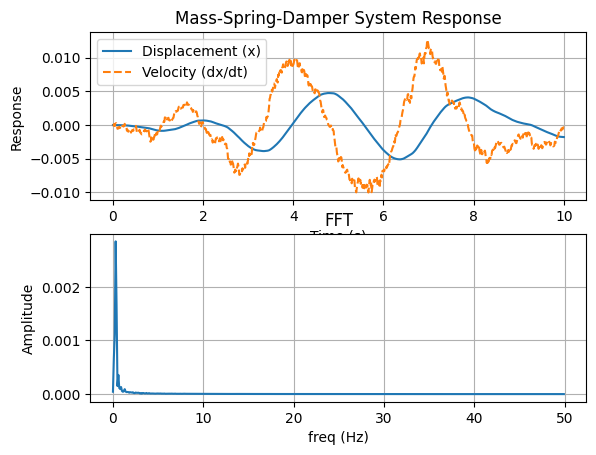

In [7]:
# view dynamics response and fft
plt.subplot(2,1,1)
plt.plot(sol.t, sol.y[0], label='Displacement (x)')
plt.plot(sol.t, sol.y[1], label='Velocity (dx/dt)', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Response')
plt.title('Mass-Spring-Damper System Response')
plt.legend()
plt.grid(True)

plt.subplot(2,1,2)
plt.plot(fft_freq, fft_mag)
plt.title('FFT')
plt.xlabel('freq (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

In [ ]:
# Build Regressor

# m*xdd + c*xd + k*x = F
# x = y and F = u
# m*y(t-2) + c * y(t-1) + k * y(t) = u
# y(t) = 1/k * (u(t) - m*y(t-2) - c * y(t-1)) , a2 = -m/k, a1 = -c/k

Phi = list() # regressor matrix
Y = list() # output vector

for t in range(2, len(sol.t)):
    Phi.append([sol.y[0][t-1], sol.y[0][t-2], sol.y[2][t]]) # a1, a2, b1
    Y.append(sol.y[0][t])


In [23]:
# least squares optimization
Phi = np.array(Phi)
Y = np.array(Y)

theta_hat, _, _, _ = np.linalg.lstsq(Phi, Y, rcond=None)
a1_hat, a2_hat, b1_hat = theta_hat

print("Actual Parameters")
print(f"a1 = {a1}, a2 ={a2}, b1 = {b1}")

print("Estimated Parameters:")
print(f"a1 = {a1_hat:.3f}, a2 = {a2_hat:.3f}, b1 = {b1_hat:.4f}")


Actual Parameters
a1 = -4.0, a2 =-0.5, b1 = 1.0
Estimated Parameters:
a1 = 1.999, a2 = -0.999, b1 = -0.0000


In [21]:
# parameter back tracking
k_hat = 1/b1_hat
m_hat = a2_hat*-1*k_hat
c_hat = a1_hat*-1*k_hat

print(f"k_hat = {k_hat:.3f}, m_hat = {m_hat:.3f}, c_hat = {c_hat:.3f}")

k_hat = -54223.015, m_hat = -54164.502, c_hat = 108366.224
